# Analytic Method: CS-01 TAS

**Purpose**: solve the Tele Assistance System as an open Jackson queueing network in closed form (M/M/c/K per node) across the full adaptation axis and check it against the Camara 2023 R1 / R2 targets.

**Inputs**: `data/config/profile/{dflt,opti}.json` (PACS-style Variable dicts) and `data/reference/baseline.json` (R1 / R2 thresholds).

**Outputs**:
- `data/results/analytic/<adaptation>/<profile>.json` - per-run metrics (nodes + network + routing + lambda_z).
- `data/results/analytic/<adaptation>/requirements.json` - R1 / R2 verdicts.
- `data/img/analytic/<adaptation>/*.png` - topology, heatmap, bars, delta figures.

**Equivalent CLI** (reproduces the four runs written by this notebook):
```bash
python -m src.methods.analytic --adaptation baseline
python -m src.methods.analytic --adaptation s1
python -m src.methods.analytic --adaptation s2
python -m src.methods.analytic --adaptation aggregate
```

This notebook is thin: all logic lives in `src.methods.analytic` and `src.view.qn_diagram`. The cells below just orchestrate, display, and save figures.

In [1]:
%matplotlib inline
from pathlib import Path

import pandas as pd

from src.methods.analytic import run
from src.view import (
    plot_qn_topology,
    plot_node_heatmap,
    plot_node_diffmap,
    plot_arch_bars,
    plot_arch_delta,
)

IMG_ROOT = Path("data/img/analytic")
ADAPTATIONS = ["baseline", "s1", "s2", "aggregate"]

# Human-readable scenario labels for plot titles / legends.
DISPLAY = {
    "baseline": "No Adaptation",
    "s1": "S1: Retry",
    "s2": "S2: Select-Reliable",
    "aggregate": "S1 & S2",
}

## 1. Solve every adaptation

`run(adp=a, wrt=True)` loads the resolved `NetCfg`, solves the Jackson network, writes the per-run envelope under `data/results/analytic/<adaptation>/`, and returns the per-node + aggregate DataFrames plus the R1 / R2 verdict.

In [2]:
results = {a: run(adp=a, wrt=True) for a in ADAPTATIONS}

# unpack the per-adaptation pieces used in every later cell
cfgs = {a: results[a]["config"] for a in ADAPTATIONS}
nodes = {a: results[a]["nodes"] for a in ADAPTATIONS}
nets = {a: results[a]["network"] for a in ADAPTATIONS}
reqs = {a: results[a]["requirements"] for a in ADAPTATIONS}

print(f"Solved {len(results)} adaptations; wrote JSONs under data/results/analytic/")

Solved 4 adaptations; wrote JSONs under data/results/analytic/


## 2. Network-wide summary + verdict

One row per adaptation: headline metrics (response time, utilisation, queue length) and the R1 / R2 pass flags.

In [3]:
rows = []
for a in ADAPTATIONS:
    n = nets[a].iloc[0]
    r = reqs[a]
    rows.append({
        "adaptation": a,
        "profile": cfgs[a].profile,
        r"$\mathbf{W_{e2e}}$ [ms]": n["W_e2e"] * 1000,
        r"$\mathbf{\varepsilon_{e2e}}$ [%]": n["eps_e2e"] * 100,
        r"$\mathbf{\overline{\rho}_{TAS}}$": n["avg_rho"],
        r"$\mathbf{\rho_{TAS,\,Max}}$": n["max_rho"],
        r"$\mathbf{L_{net}}$": n["L_net"],
        "R1 (≤ 1.0%)": "PASS" if r["R1"]["pass"] else "FAIL",
        "R2 (≤ 26 ms)": "PASS" if r["R2"]["pass"] else "FAIL",
    })
summary = pd.DataFrame(rows).set_index("adaptation")
summary.round(4)

,profile,$\mathbf{W_{e2e}}$ [ms],$\mathbf{\varepsilon_{e2e}}$ [%],$\mathbf{\overline{\rho}_{TAS}}$,"$\mathbf{\rho_{TAS,\,Max}}$",$\mathbf{L_{net}}$,R1 (≤ 1.0%),R2 (≤ 26 ms)
adaptation,,,,,,,,
baseline,dflt,25.7402,14.8216,0.2927,0.6499,7.0818,FAIL,PASS
s1,opti,27.7147,0.2048,0.3218,0.7167,8.6569,PASS,FAIL
s2,opti,18.5294,10.4216,0.2562,0.5685,5.1953,FAIL,PASS
aggregate,opti,19.4013,0.0714,0.2806,0.6318,6.0683,PASS,PASS


## 3. Per-node snapshot (baseline)

The reference configuration before any adaptation kicks in. `rho = lambda / (c * mu)`; `W`, `Wq` are in seconds; `L`, `Lq` are mean request counts.

In [4]:
nodes["baseline"][[
    "key", "name", "type", "lambda", "mu", "c", "K",
    "rho", "L", "W",
]].round(4)

,key,name,type,lambda,mu,c,K,rho,L,W
0,TAS_{1},TAS composite stage 1 (dispatch),M/M/s/K,323.0000,7.500000e+02,1,16,0.4307,0.7564,0.0023
1,TAS_{2},TAS composite stage 2 (medical dispatch),M/M/s/K,242.2500,7.500000e+02,1,16,0.3230,0.4771,0.0020
2,TAS_{3},TAS composite stage 3 (alarm dispatch),M/M/s/K,153.0006,7.500000e+02,1,16,0.2040,0.2563,0.0017
3,MAS_{1},Medical Analysis Service 1,M/M/s/K,90.8438,1.820000e+02,1,16,0.4991,0.9964,0.0110
4,MAS_{2},Medical Analysis Service 2,M/M/s/K,88.5645,5.320000e+02,1,16,0.1665,0.1997,0.0023
5,MAS_{3},Medical Analysis Service 3,M/M/s/K,97.4909,1.500000e+02,1,16,0.6499,1.8454,0.0189
6,AS_{1},Alarm Service 1,M/M/s/K,56.7306,7.020000e+02,1,16,0.0808,0.0879,0.0015
7,AS_{2},Alarm Service 2,M/M/s/K,54.1877,4.110000e+02,1,16,0.1318,0.1519,0.0028
8,AS_{3},Alarm Service 3,M/M/s/K,61.5734,1.579000e+03,1,16,0.0390,0.0406,0.0007
9,TAS_{4},TAS composite stage 4 (drug dispatch),M/M/s/K,242.2500,7.500000e+02,1,16,0.3230,0.4771,0.0020


## 4. Queue-network topology (architecture view)

Nodes are coloured by `rho` (cool = low, warm = high). Edge labels show routing probabilities.

In [5]:
# remove FAIL node to simplify renders
# FAIL_{1} (the absorbing failure sink) stays in the SOLVE for availability
# (eps_e2e = lambda_FAIL/lambda_z); here we drop it from the per-node figures below so the
# topology + heatmaps render the 13-node service mesh. FAIL_{1} is the last node, so slice it off.
# The section 3 table above keeps it (it runs before this cell).
FAIL_KEY = "FAIL_{1}"
nodes = {a: df[df["key"] != FAIL_KEY].reset_index(drop=True) for a, df in nodes.items()}
routs = {a: cfgs[a].routing[:-1, :-1] for a in ADAPTATIONS}

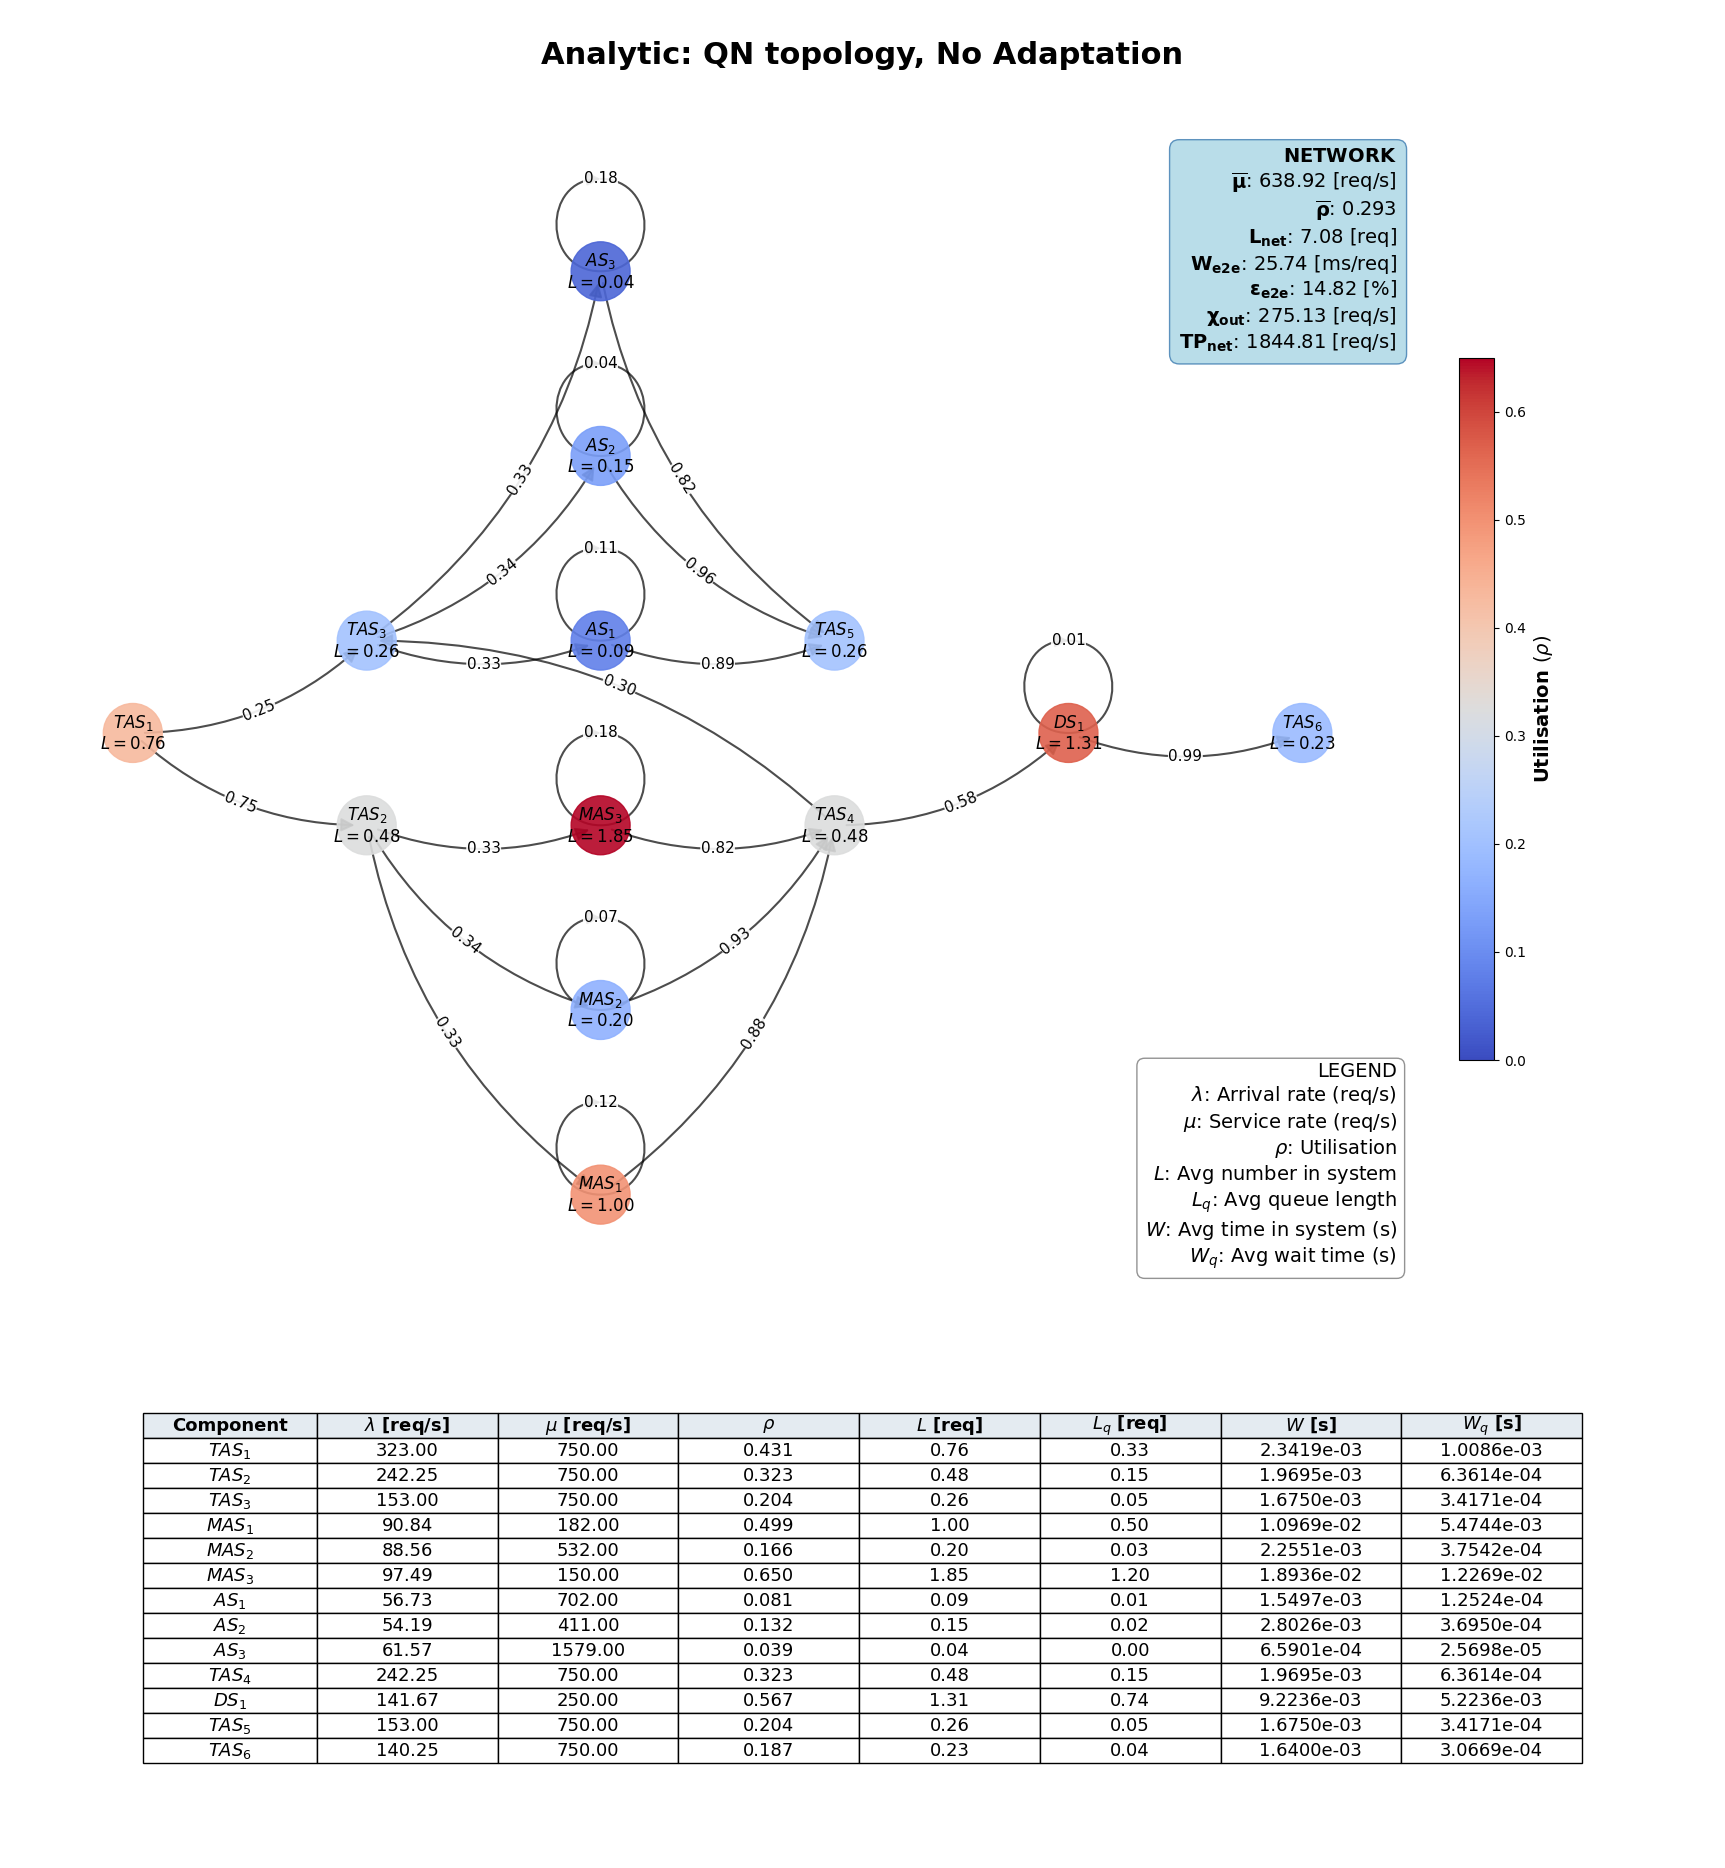

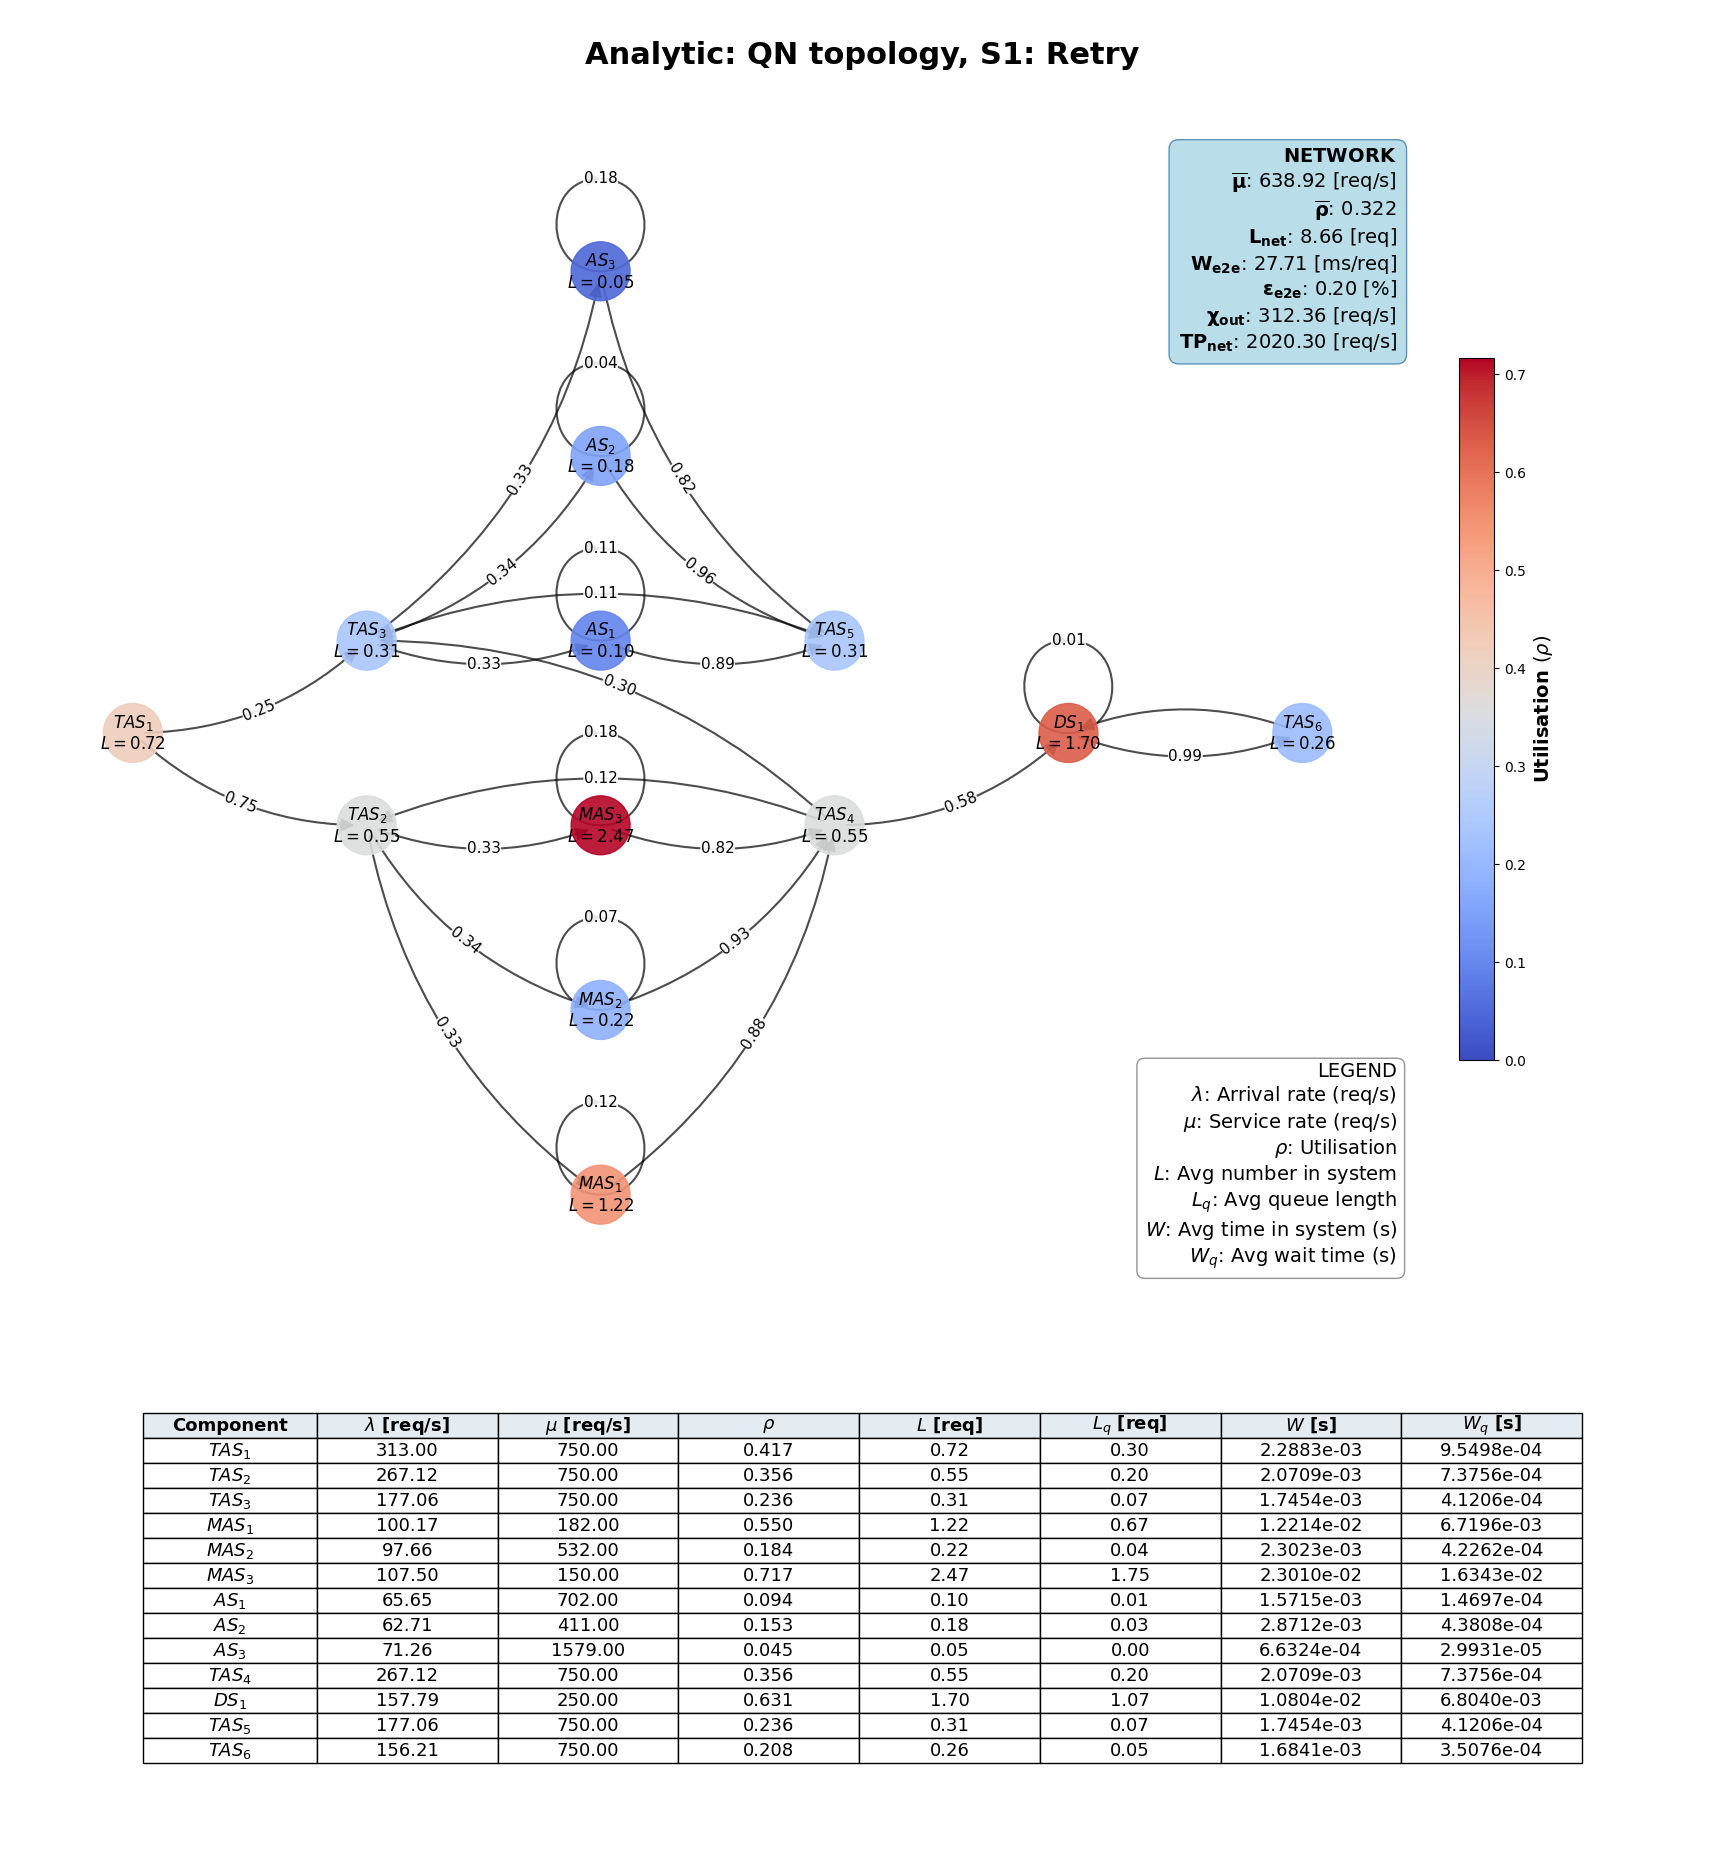

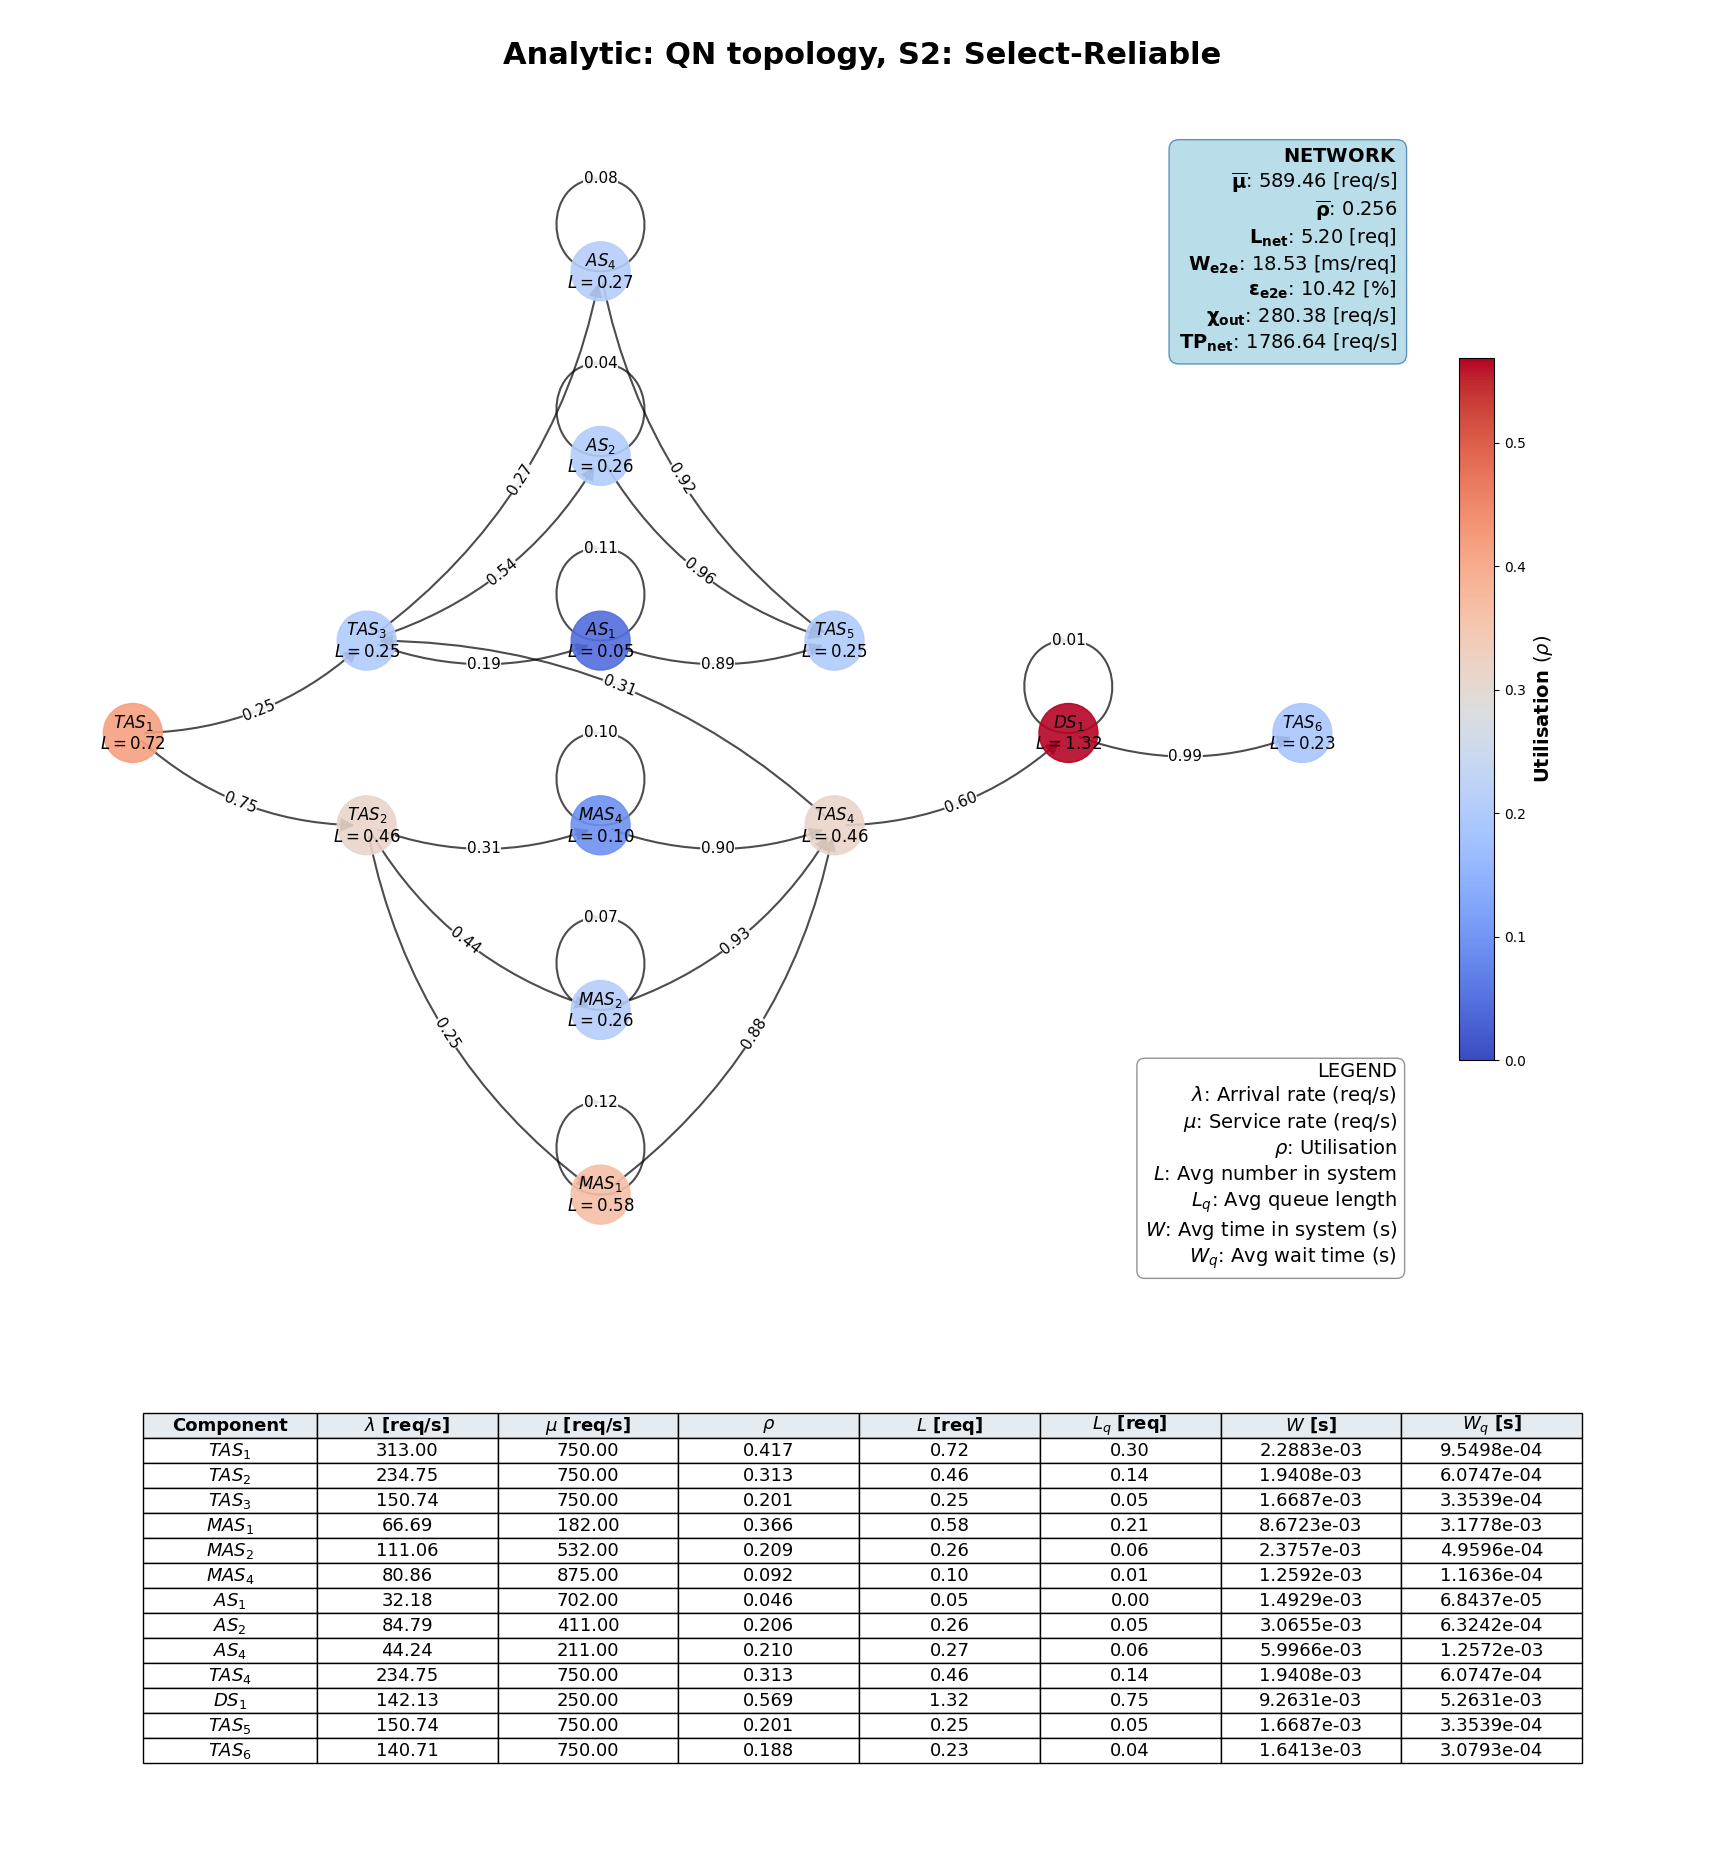

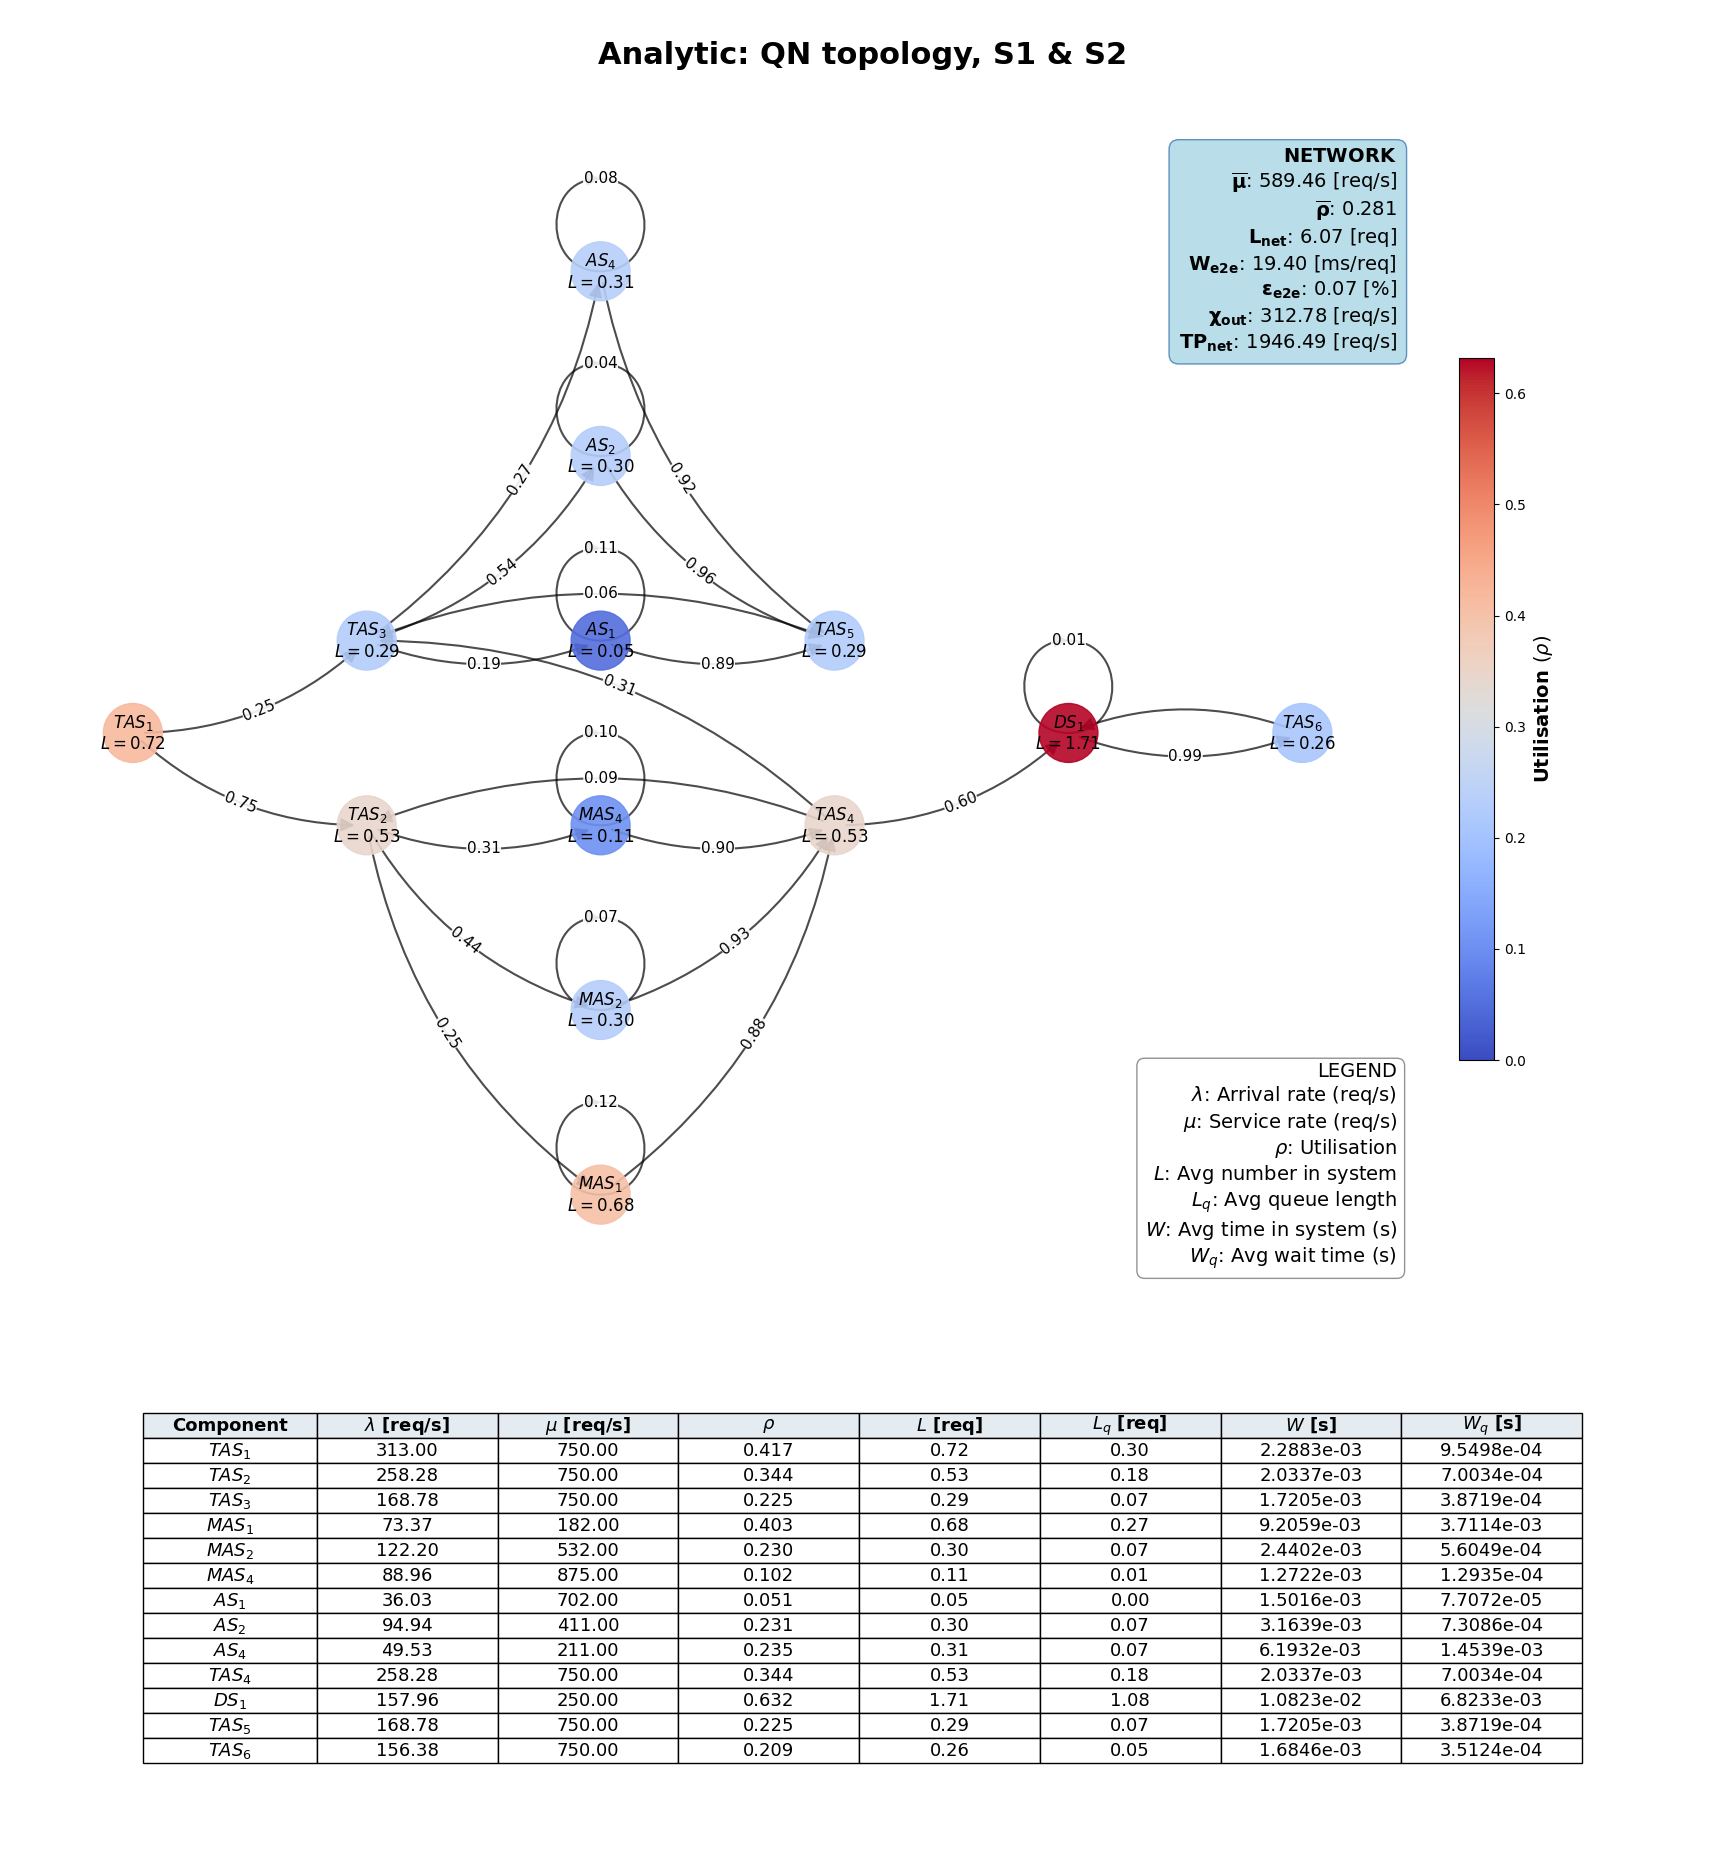

In [6]:
# standalone topology for every adaptation -> data/img/analytic/<adp>/topology.png
# routs/nodes are the FAIL-filtered views from the cell above (13-node service mesh).
for a in ADAPTATIONS:
    plot_qn_topology(
        routs=routs[a],
        ndss=nodes[a],
        nets=nets[a],
        title=f"Analytic: QN topology, {DISPLAY[a]}",
        file_path=str(IMG_ROOT / a),
        fname="topology.png")

## 5. Per-node heatmap (before vs after)

Each row = one artifact; each column = one metric. Columns are normalised per-metric across both scenarios so the heat value is directly comparable. Numeric cell labels show the raw value.

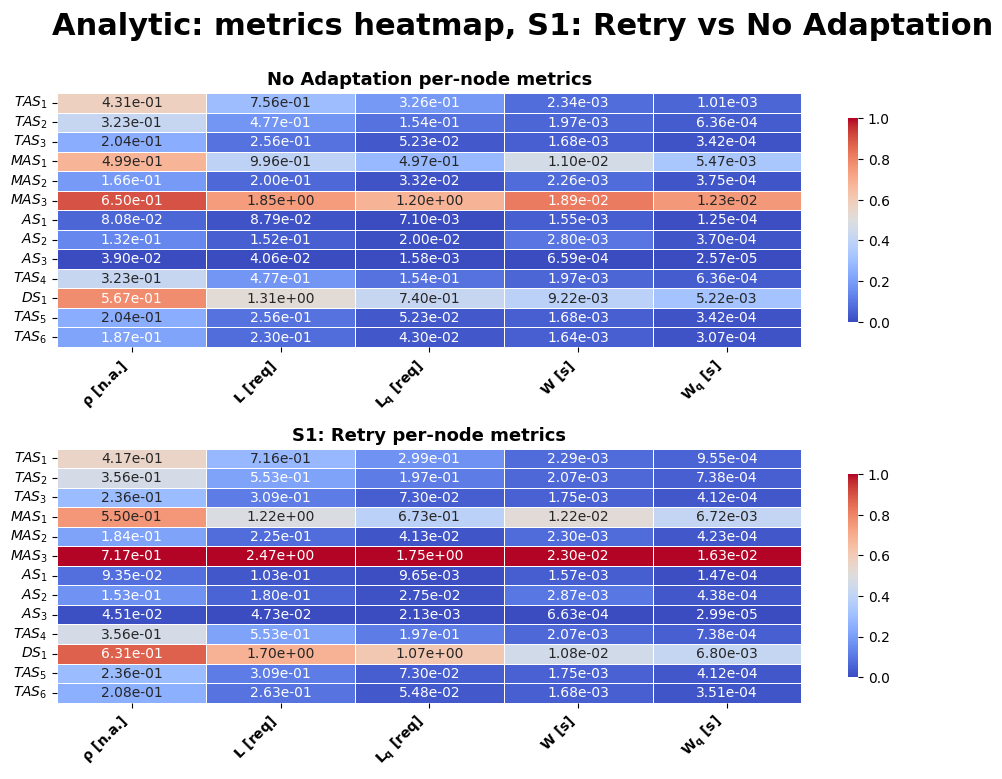

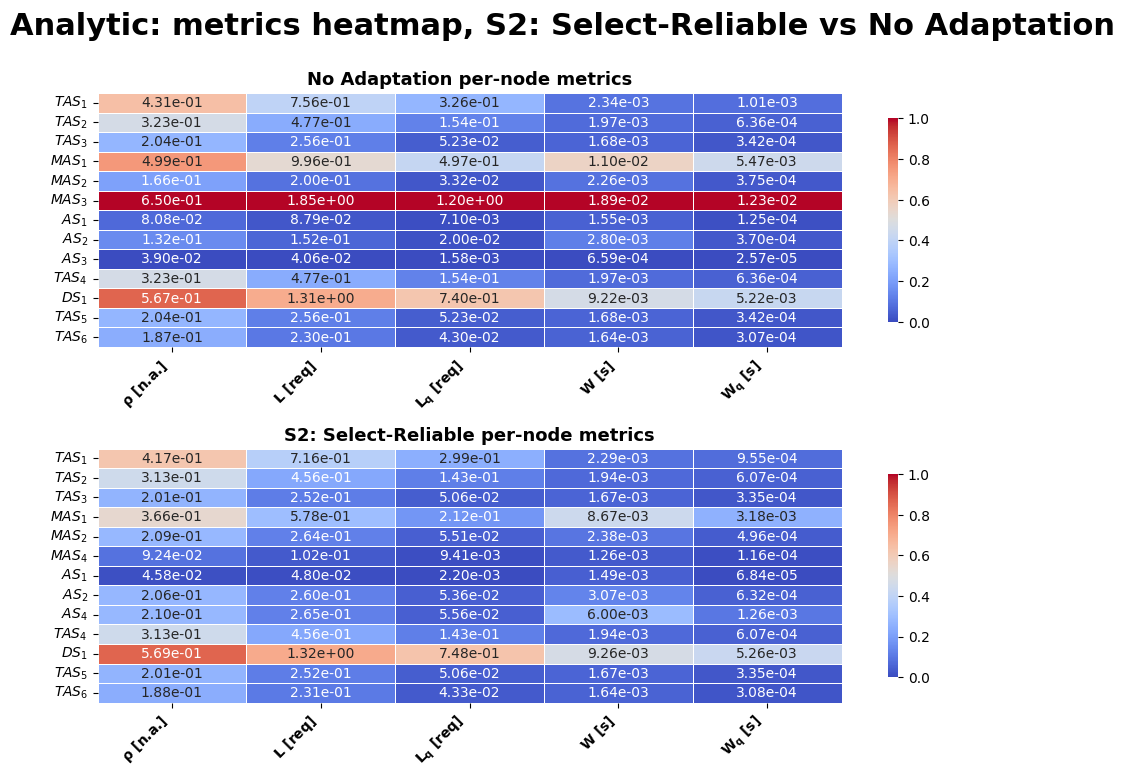

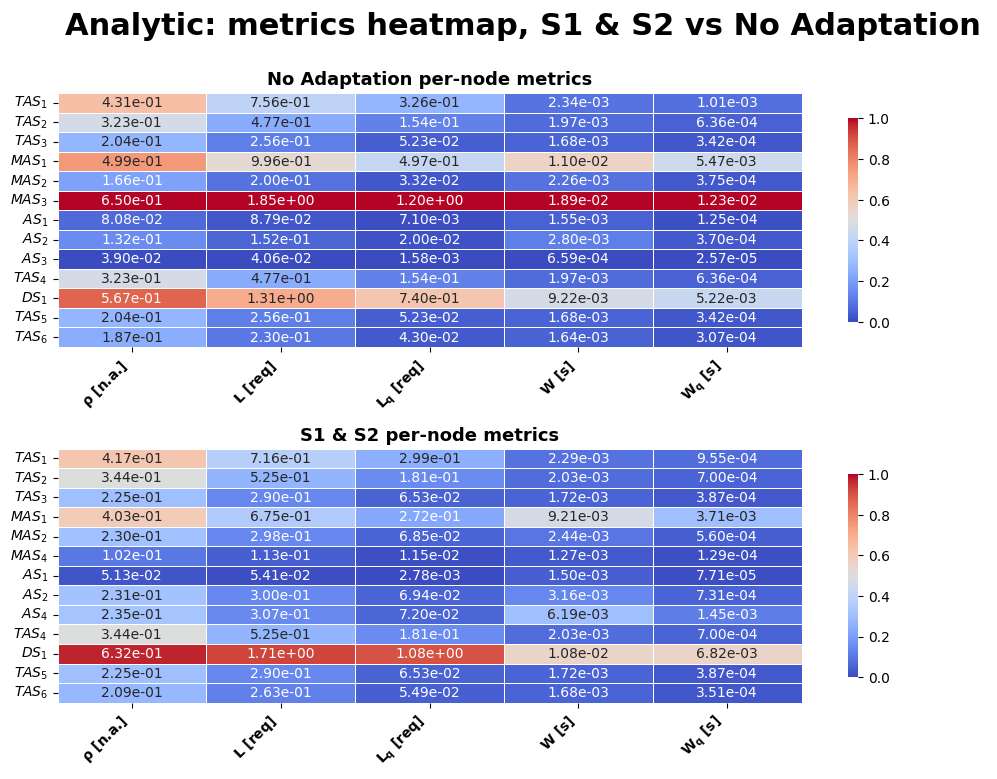

In [7]:
heat_metrics = ["rho", "L", "Lq", "W", "Wq"]
heat_labels = [
    r"$\mathbf{\rho}$ [n.a.]",
    r"$\mathbf{L}$ [req]",
    r"$\mathbf{L_q}$ [req]",
    r"$\mathbf{W}$ [s]",
    r"$\mathbf{W_q}$ [s]",
]

# plot_node_heatmap aligns rows positionally (iloc[i]); each panel's y-axis labels come from its own `key` column, so swap-slot rows show baseline's MAS_{3}/AS_{3}/DS_{3} and s2/aggregate's MAS_{4}/AS_{4}/DS_{1} at the same row position.
for a in ["s1", "s2", "aggregate"]:
    plot_node_heatmap(
        ndss=[nodes["baseline"], nodes[a]],
        names=[DISPLAY["baseline"], DISPLAY[a]],
        metrics=heat_metrics,
        labels=heat_labels,
        title=f"Analytic: metrics heatmap, {DISPLAY[a]} vs {DISPLAY['baseline']}",
        file_path=str(IMG_ROOT / a),
        fname="heatmap_vs_baseline.png")

## 5b. Per-node delta heatmap (Δ% vs baseline)

Single-panel view of the per-node, per-metric percent change between baseline and each adaptation. Centred diverging colour scale so positive and negative changes read as equal-intensity colours.

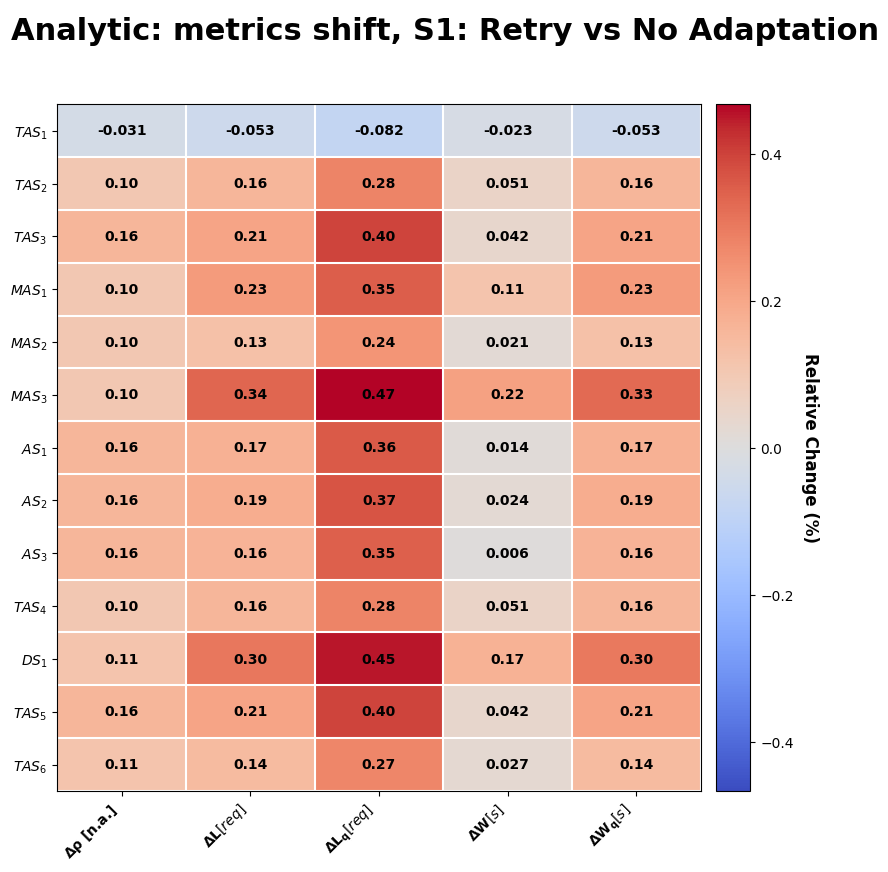

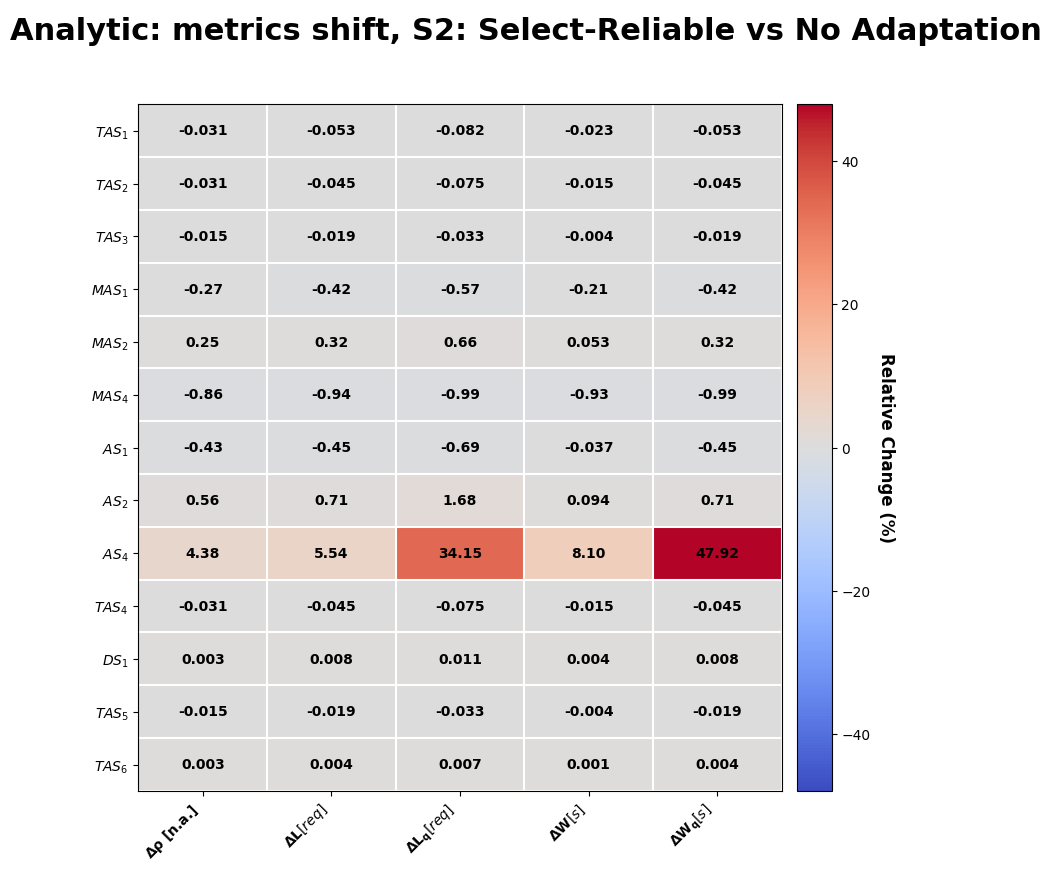

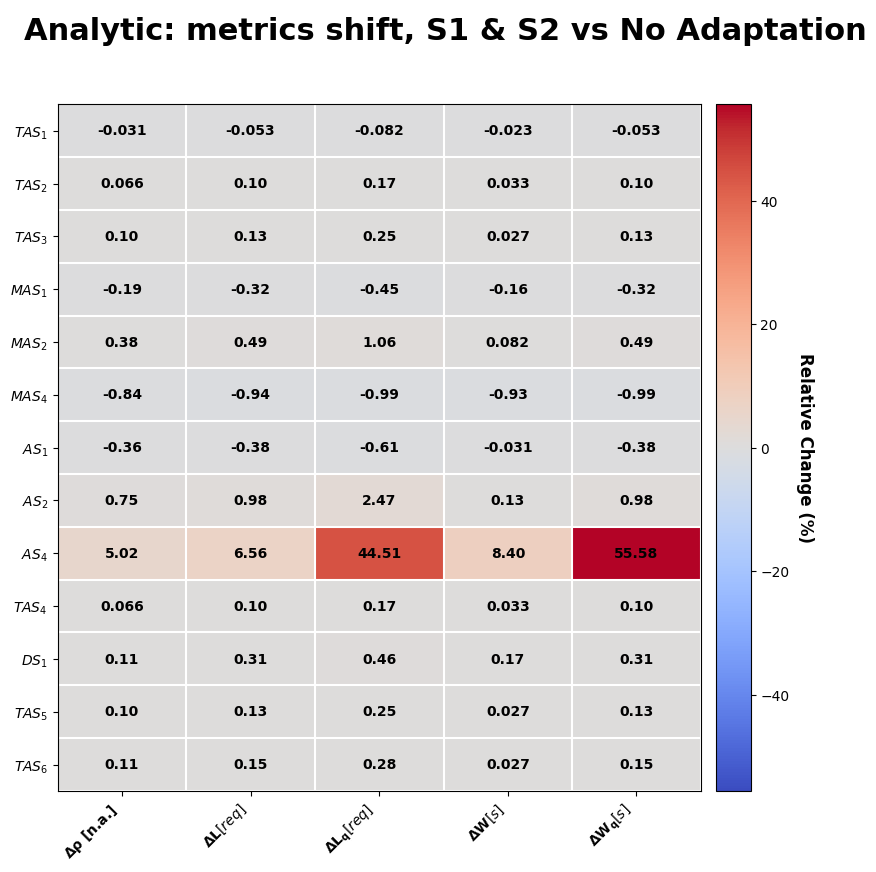

In [8]:
# single-panel delta heatmap per adaptation -> data/img/analytic/<adp>/nd_diffmap_vs_baseline.png
# Match the OLD convention: delta = (opti - dflt) / |dflt| -- ratio, not percent.
# Align by positional index (slot) since `key` may differ at swap slots (baseline MAS_{3} vs s2 MAS_{4});
# the y-axis carries each adp's actual service keys.
diff_metrics = ["rho", "L", "Lq", "W", "Wq"]
diff_labels = [
    r"$\mathbf{\Delta \rho}$ [n.a.]",
    r"$\mathbf{\Delta L} [req]$",
    r"$\mathbf{\Delta L_q} [req]$",
    r"$\mathbf{\Delta W} [s]$",
    r"$\mathbf{\Delta W_q} [s]$",
]

bl_nodes = nodes["baseline"]
for a in ["s1", "s2", "aggregate"]:
    ac_nodes = nodes[a]
    rows = []
    for i in range(len(ac_nodes)):
        b_row = bl_nodes.iloc[i]
        c_row = ac_nodes.iloc[i]
        row = {"key": c_row["key"]}
        for m in diff_metrics:
            b, c = float(b_row[m]), float(c_row[m])
            row[m] = ((c - b) / abs(b)) if b else 0.0
        rows.append(row)
    deltas = pd.DataFrame(rows)

    plot_node_diffmap(
        deltas=deltas,
        nodes=deltas["key"].tolist(),
        metrics=diff_metrics,
        labels=diff_labels,
        title=f"Analytic: metrics shift, {DISPLAY[a]} vs {DISPLAY['baseline']}",
        file_path=str(IMG_ROOT / a),
        fname="nd_diffmap_vs_baseline.png")

## 6. Network-wide bars (all four adaptations)

Headline comparison of the four configurations on the metrics that drive the R1 / R2 verdicts. Y-axis is log-scaled because the metrics span several orders of magnitude (W in seconds vs L in requests).

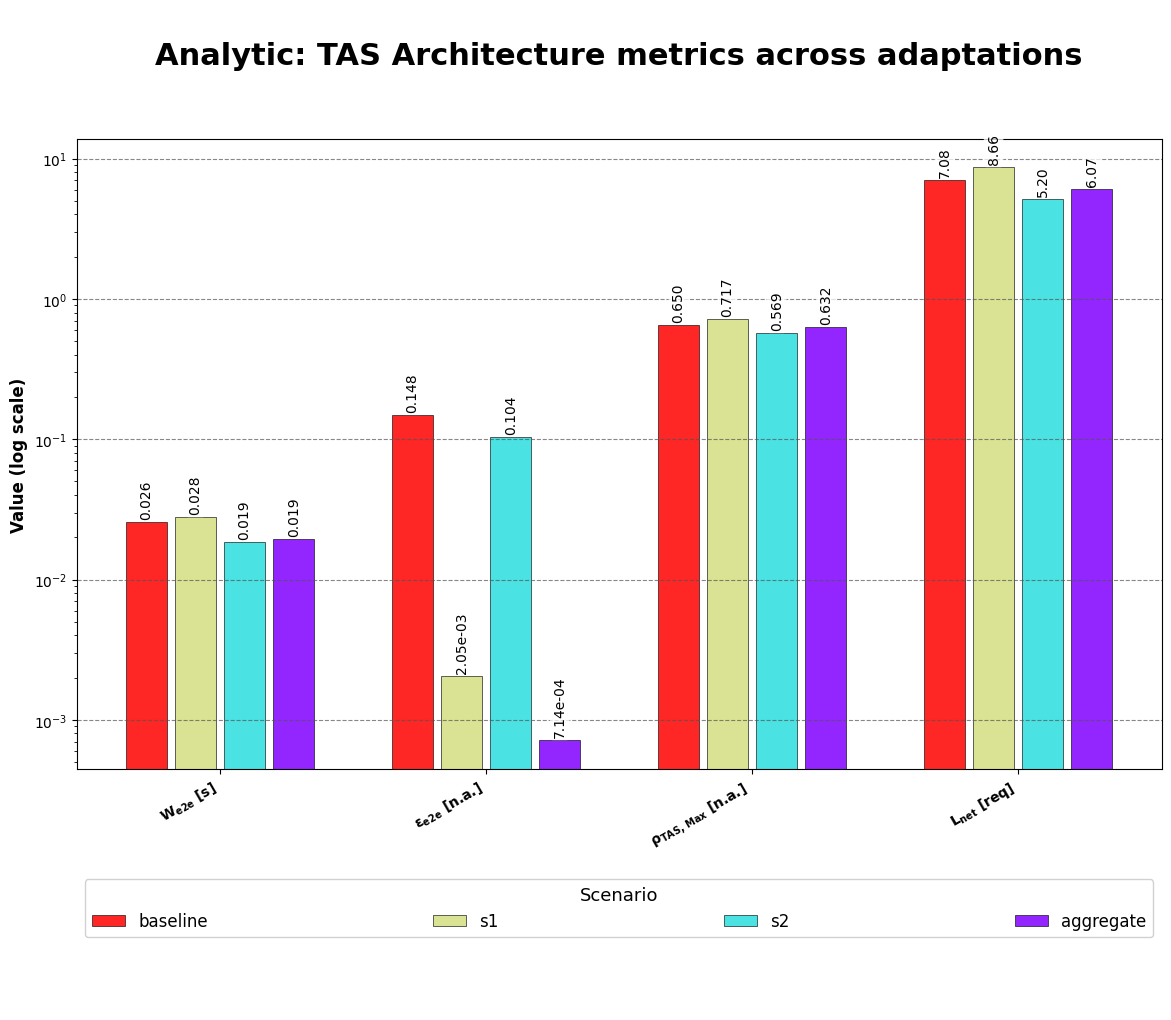

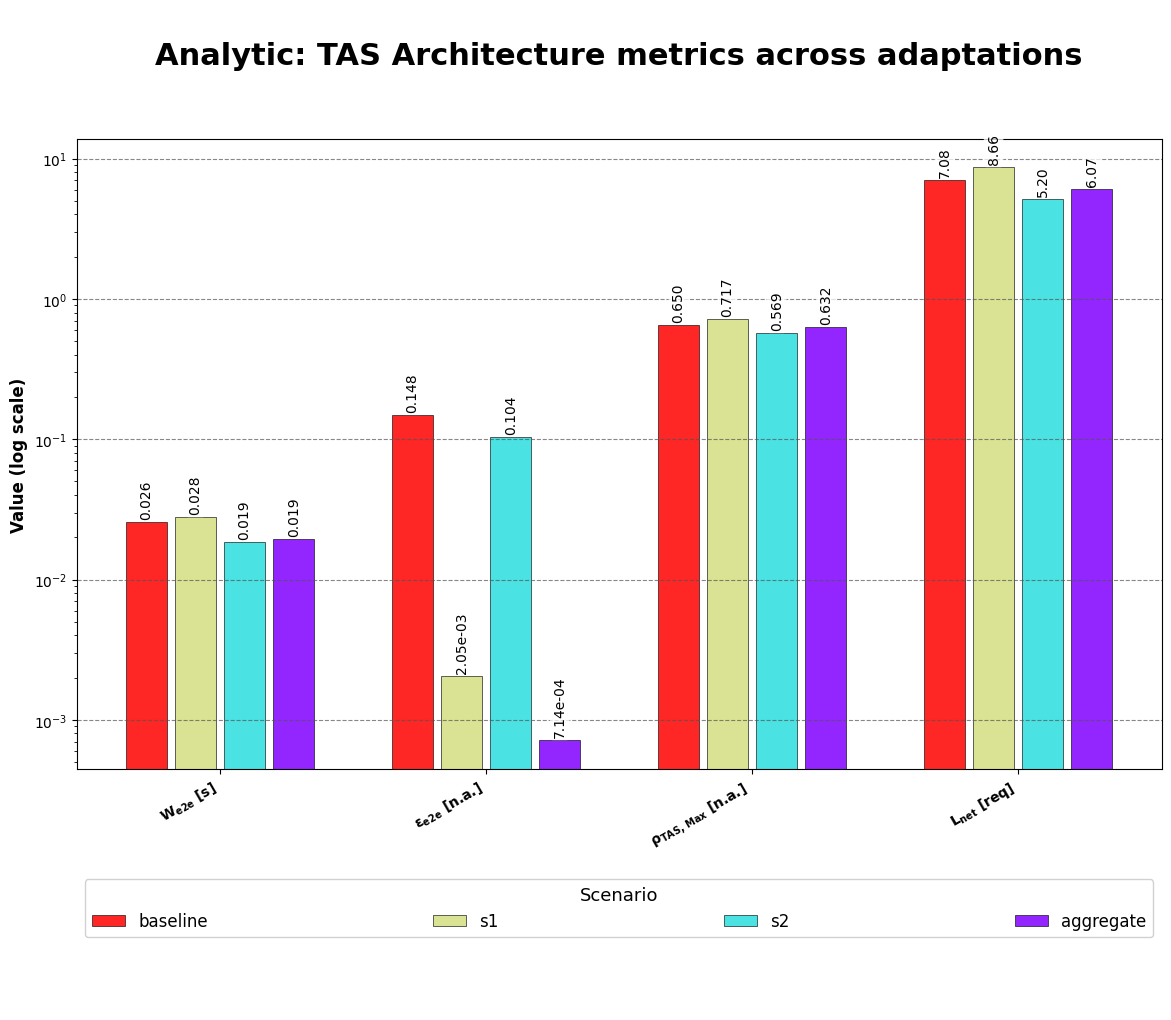

In [9]:
bar_metrics = ["W_e2e", "eps_e2e", "max_rho", "L_net"]
bar_labels = [
    r"$\mathbf{W_{e2e}}$ [s]",
    r"$\mathbf{\varepsilon_{e2e}}$ [n.a.]",
    r"$\mathbf{\rho_{TAS,\,Max}}$ [n.a.]",
    r"$\mathbf{L_{net}}$ [req]",
]

plot_arch_bars(
    nets=[nets[a] for a in ADAPTATIONS],
    names=ADAPTATIONS,
    metrics=bar_metrics,
    labels=bar_labels,
    title="Analytic: TAS Architecture metrics across adaptations",
    file_path=str(IMG_ROOT / "aggregate"),
    fname="net_bars_all.png")

## 7. Network-wide delta (% change vs baseline)

For every non-baseline adaptation: fractional change on the headline metrics. Green bars = improvement, red = degradation. `total_throughput` flips the sign convention (more is better).

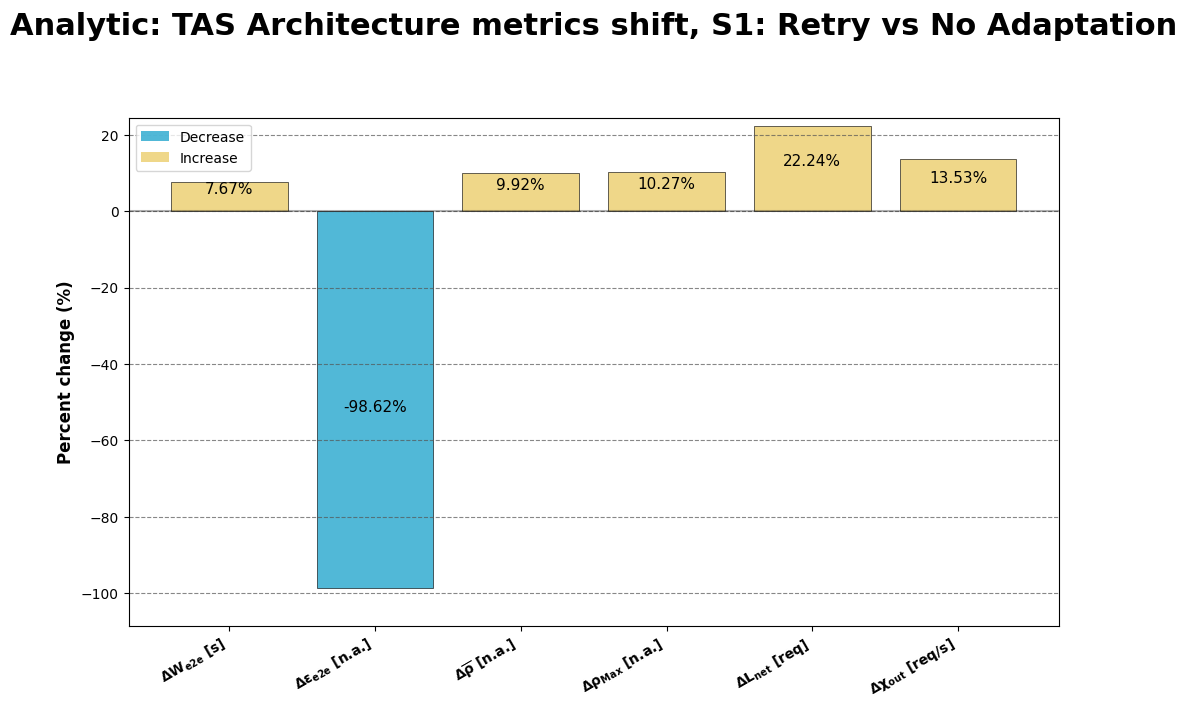

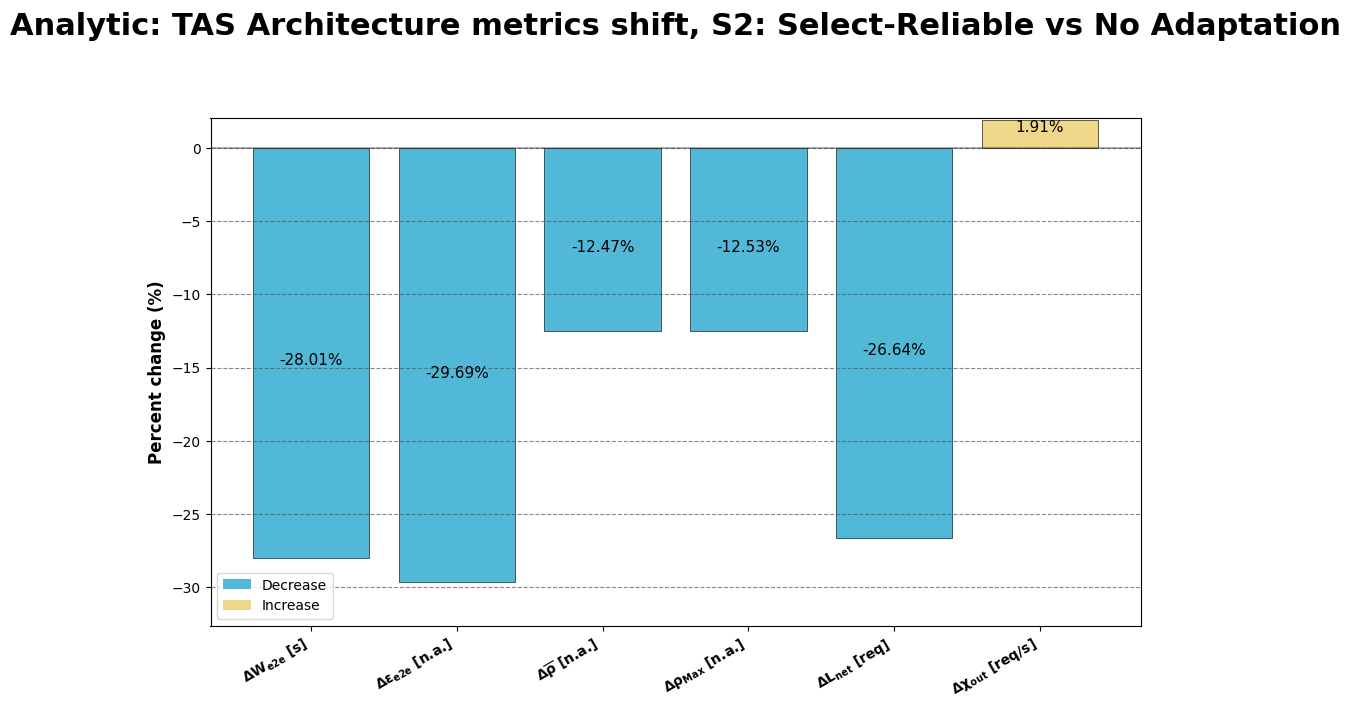

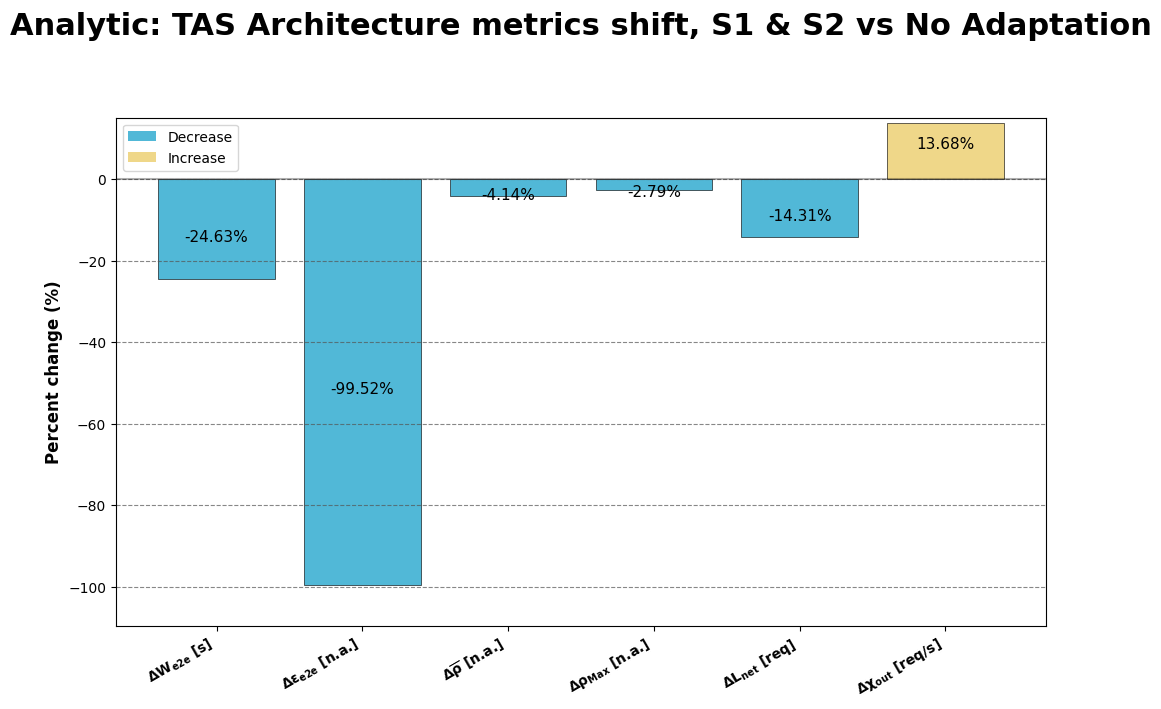

In [10]:
# fractional delta vs baseline for each non-baseline adaptation.
delta_metrics = [
    "W_e2e",
    "eps_e2e",
    "avg_rho",
    "max_rho",
    "L_net",
    "chi_out",
]

delta_labels = [
    r"$\mathbf{\Delta W_{e2e}}$ [s]",
    r"$\mathbf{\Delta \varepsilon_{e2e}}$ [n.a.]",
    r"$\mathbf{\Delta \overline{\rho}}$ [n.a.]",
    r"$\mathbf{\Delta \rho_{Max}}$ [n.a.]",
    r"$\mathbf{\Delta L_{net}}$ [req]",
    r"$\mathbf{\Delta \chi_{out}}$ [req/s]",
]

bl = nets["baseline"].iloc[0]
for a in ["s1", "s2", "aggregate"]:
    ac = nets[a].iloc[0]
    row = {
        m: (ac[m] - bl[m]) / bl[m] if bl[m] else 0.0
        for m in delta_metrics
    }
    plot_arch_delta(
        deltas=pd.DataFrame([row]),
        metrics=delta_metrics,
        labels=delta_labels,
        title=f"Analytic: TAS Architecture metrics shift, {DISPLAY[a]} vs {DISPLAY['baseline']}",
        file_path=str(IMG_ROOT / a),
        fname="net_delta_vs_baseline.png")

## 8. R1 / R2 verdict table

Thresholds come from [`data/reference/baseline.json`](data/reference/baseline.json):

- **R1** Availability: `eps_e2e <= 1.00 %` (Weyns 2015 SEAMS)
- **R2** Performance: `W_e2e <= 26 ms` (Camara 2023)

End-to-end values come from the **loss-network** model: failures are routing leaks that terminate at the absorbing `FAIL_{1}` sink, so availability is read directly from flow:

- `eps_e2e = lambda_FAIL / lambda_z` (failed fraction; the flow absorbed at the FAIL sink)
- `chi_out = lambda_z - lambda_FAIL` (effective successful-completion rate)
- `W_e2e = L_net / chi_out` (per-request end-to-end response time)

Failure is applied at the workflow handlers (`TAS_4` medical, `TAS_5` alarm, `TAS_6` drug) using the dispatch-weighted pool failure; each handler's give-up flow to `FAIL_{1}` is its R1 contribution (they sum to `eps_e2e`). Retry (S1 / aggregate) re-dispatches failed calls through the handler back to the pool, so the residual giving up shrinks to `~ f^k`. The table below carries the verdict per adaptation alongside the single top contributor node, the evidence trail for why each scenario passes or fails. Full top-3 contributor lists land in `data/results/analytic/<adp>/requirements.json`.

In [11]:
req_rows = []
for a in ADAPTATIONS:
    r = reqs[a]
    n = nets[a].iloc[0]
    # extract the top R1 / R2 contributor as evidence
    r1_top = r["R1"]["contributions"][0] if r["R1"].get("contributions") else {}
    r2_top = r["R2"]["contributions"][0] if r["R2"].get("contributions") else {}
    req_rows.append({
        "adaptation": a,
        "eps_e2e [%]": round(r["R1"]["value"] * 100, 3),
        "R1 (≤ 1%)": "PASS" if r["R1"]["pass"] else "FAIL",
        "R1 top contributor": f"{r1_top.get('node','-')} ({r1_top.get('contribution',0)*100:.2f}%)" if r1_top else "-",
        "W_e2e [ms]": round(r["R2"]["value"] * 1000, 3),
        "R2 (≤ 26 ms)": "PASS" if r["R2"]["pass"] else "FAIL",
        "R2 top contributor": f"{r2_top.get('node','-')} ({r2_top.get('share',0)*100:.1f}%)" if r2_top else "-",
    })
pd.DataFrame(req_rows).set_index("adaptation")

,eps_e2e [%],R1 (≤ 1%),R1 top contributor,W_e2e [ms],R2 (≤ 26 ms),R2 top contributor
adaptation,,,,,,
baseline,14.822,FAIL,TAS_{4} (9.21%),25.740,PASS,MAS_{3} (26.1%)
s1,0.205,PASS,TAS_{4} (0.14%),27.715,FAIL,MAS_{3} (28.5%)
s2,10.422,FAIL,TAS_{4} (6.89%),18.529,PASS,DS_{1} (25.3%)
aggregate,0.071,PASS,TAS_{4} (0.06%),19.401,PASS,DS_{1} (28.2%)


## Summary

At the locked envelope (`lambda_z = 323 req/s` E-QS canonical inflection), the loss-network analytic model produces a clean performance-vs-availability trade-off:

- **R1 (Availability, `eps_e2e <= 1%`): baseline and S2 fail; S1 and the aggregate pass.** With no recovery, failures stay unrecovered at `eps_e2e = 14.8%` (baseline). Retry recovers availability multiplicatively (residual `~ f^k`), so `S1` drops to 0.2% and the aggregate to 0.07%. `S2 (Select-Reliable)` only biases dispatch toward the more reliable services and swaps in the lower-eps catalogue (`MAS_{4}` / `AS_{4}`), cutting failures to 10.4%, better than baseline but not below 1% on a single attempt.
- **R2 (Performance, `W_e2e <= 26 ms`): baseline, S2, and the aggregate pass; S1 fails.** Retry's re-dispatch traffic overloads the pools (`rho_max = 0.72`) and pushes `W_e2e` to 27.7 ms, just over the ceiling. Selection lowers latency (faster reliable services, 18.5 ms); the aggregate keeps the load down via reliable dispatch (19.4 ms) while still recovering availability.

The trade-off reads cleanly: **retry buys availability at a performance cost, selection buys performance but not enough availability, and only the aggregate (selection + retry) satisfies both R1 and R2.** Per the section 8 contributor lists, the medical handler `TAS_{4}` is the top R1 leak in every scenario; `MAS_{3}` dominates R2 under baseline / S1 and `DS_{1}` under S2 / aggregate (the catalogue swap leaves the drug service as the slowest surviving stage).

**Next method in the pipeline**: `02-stochastic.ipynb` (SimPy DES) cross-checks these closed-form values against discrete-event simulation, and `03-dimensional.ipynb` reads the same envelope through the DASA dimensional bounds (`sigma_R2`, `eta_R1`).